# Last-throw search density

Compare sparse and dense throw grids, plus a 1,000-throw random search, on the same randomly generated last-throw positions. The `(20, 20, 6)` grid is the reference search.

In [28]:
from pathlib import Path
import sys

import importlib
import numpy as np

# Jupyter often starts in scratch/, so add the repository root explicitly.
repo_root = Path.cwd()
if not (repo_root / "data_generation.py").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import data_generation
import scratch.last_throw_search_grid_density as experiment
experiment = importlib.reload(experiment)

NUM_SIMS = 100
TEAM = 1
GRID_SIZES = [(10, 10, 4), (20, 20, 6), (5, 5, 2)]
RANDOM_THROWS_PER_STATE = 2000
TARGET_TRAJECTORIES_PER_PHYSICS_CALL = 4096
SEED = 0


In [5]:
np.random.seed(SEED)
sheet_states = data_generation.random_sheet_states(
    team1=5, team2=4, num_sims=NUM_SIMS
)
assert np.all(sheet_states.next_team_to_play() == TEAM)

grid_results, random_result, summaries, per_sim = experiment.run_experiment(
    sheet_states,
    team=TEAM,
    grid_sizes=GRID_SIZES,
    random_throws_per_state=RANDOM_THROWS_PER_STATE,
    target_trajectories=TARGET_TRAJECTORIES_PER_PHYSICS_CALL,
    seed=SEED,
)
summaries["grid"]


grid (10, 10, 4): 1,200 candidates/state in 5.9s
grid (20, 20, 6): 7,200 candidates/state in 36.4s
grid (5, 5, 2): 150 candidates/state in 0.7s
random 2000: 2,000 candidates/state in 10.2s


[{'grid': (10, 10, 4),
  'candidates_per_state': 1200,
  'fraction_below_dense_reference': np.float64(0.07),
  'mean_reference_minus_grid_score': np.float64(0.05),
  'max_reference_minus_grid_score': np.int64(2),
  'median_num_best_throws': np.float64(19.5)},
 {'grid': (20, 20, 6),
  'candidates_per_state': 7200,
  'fraction_below_dense_reference': np.float64(0.0),
  'mean_reference_minus_grid_score': np.float64(0.0),
  'max_reference_minus_grid_score': np.int64(0),
  'median_num_best_throws': np.float64(123.5)},
 {'grid': (5, 5, 2),
  'candidates_per_state': 150,
  'fraction_below_dense_reference': np.float64(0.34),
  'mean_reference_minus_grid_score': np.float64(0.45),
  'max_reference_minus_grid_score': np.int64(5),
  'median_num_best_throws': np.float64(5.0)}]

In [16]:
summaries["random"]

per_sim


sim_idx,version,best_score_this_version,best_score_all_versions,num_occurrences
i64,str,i64,i64,i64
0,"""grid_(10, 10, 4)""",2,2,33
1,"""grid_(10, 10, 4)""",2,2,2
2,"""grid_(10, 10, 4)""",3,3,189
3,"""grid_(10, 10, 4)""",3,3,1
4,"""grid_(10, 10, 4)""",3,3,2
…,…,…,…,…
95,"""random""",4,4,161
96,"""random""",4,4,1
97,"""random""",3,3,78


(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Dense-grid score minus grid score'}, xlabel='score gap', ylabel='simulations'>,
        <Axes: title={'center': 'Dense-grid score minus random-search score'}, xlabel='score gap', ylabel='simulations'>],
       dtype=object))

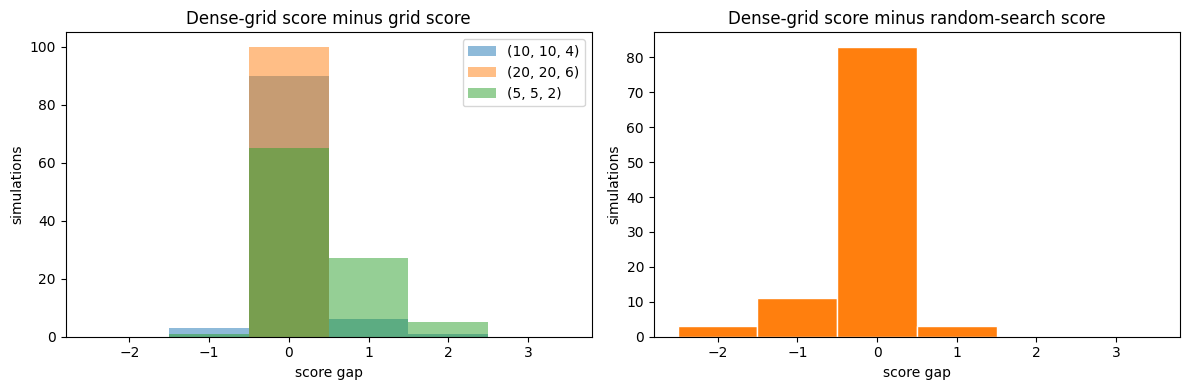

In [17]:
experiment.plot_score_gaps(grid_results, random_result)


In [18]:
experiment.overall_best_frequency(per_sim)


version,overall_best_count,num_simulations,overall_best_fraction
str,u32,u32,f64
"""grid_(10, 10, 4)""",80,100,0.8
"""grid_(20, 20, 6)""",84,100,0.84
"""grid_(5, 5, 2)""",55,100,0.55
"""random""",95,100,0.95


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Gaps when a version is not overall best'}, xlabel='gap from overall best', ylabel='simulations'>)

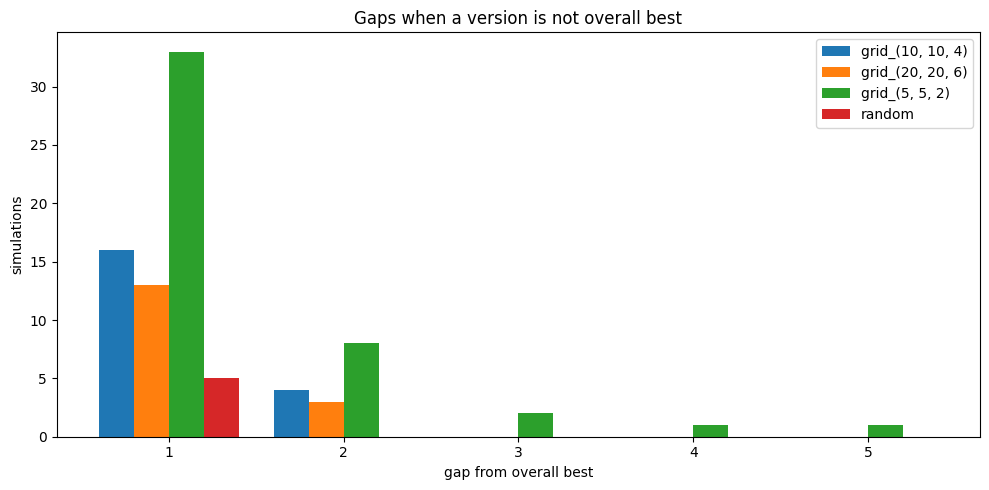

In [35]:
import polars as pl
experiment.plot_gap_distributions(per_sim)

(<Figure size 1000x800 with 4 Axes>,
 array([[<Axes: title={'center': 'grid_(10, 10, 4)'}, xlabel='number of best-score throws', ylabel='simulations'>,
         <Axes: title={'center': 'grid_(20, 20, 6)'}, xlabel='number of best-score throws', ylabel='simulations'>],
        [<Axes: title={'center': 'grid_(5, 5, 2)'}, xlabel='number of best-score throws', ylabel='simulations'>,
         <Axes: title={'center': 'random'}, xlabel='number of best-score throws', ylabel='simulations'>]],
       dtype=object))

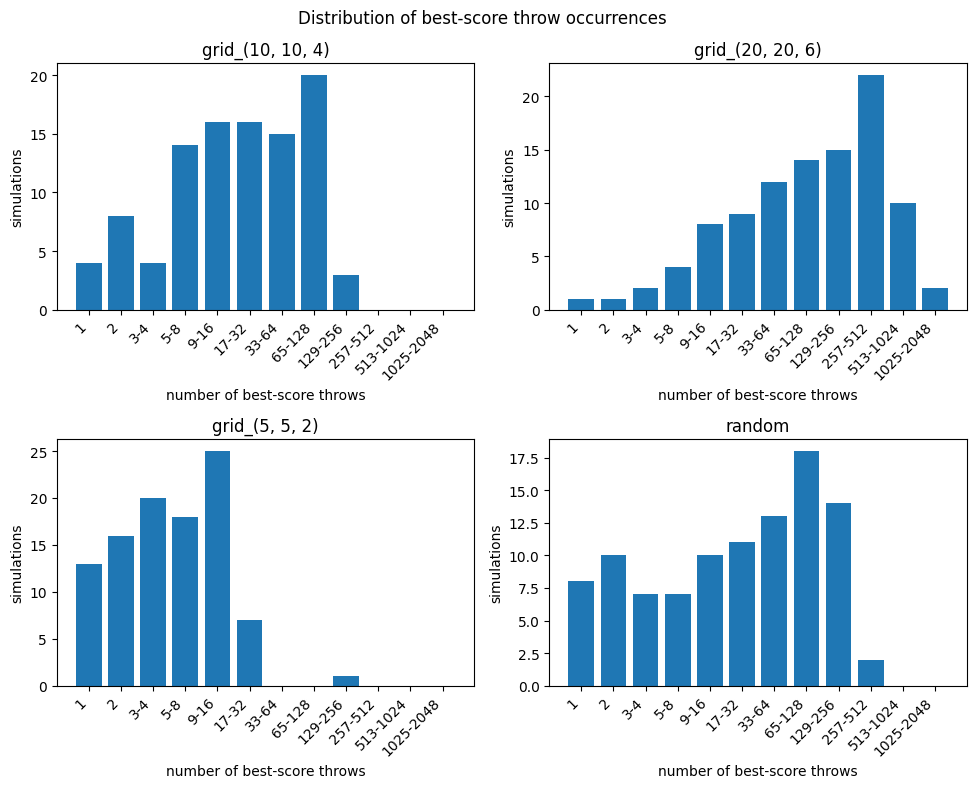

In [29]:
experiment.plot_best_occurrence_distributions(per_sim)
